In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [4]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

In [5]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [6]:
imputer = SimpleImputer(strategy='mean')

df.iloc[:, 1:] = imputer.fit_transform(df.iloc[:, 1:])

In [7]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 0,
    'B': 1
})

In [8]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [10]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [12]:
svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [13]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'degree': [2, 3]
}

In [14]:
grid_search = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3],
                         'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [15]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}


In [16]:
best_model = grid_search.best_estimator_

In [17]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [18]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Accuracy: 0.9534883720930233
Precision: 0.9310344827586207
Recall: 1.0
F1 Score: 0.9642857142857143


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93        32
           1       0.93      1.00      0.96        54

    accuracy                           0.95        86
   macro avg       0.97      0.94      0.95        86
weighted avg       0.96      0.95      0.95        86



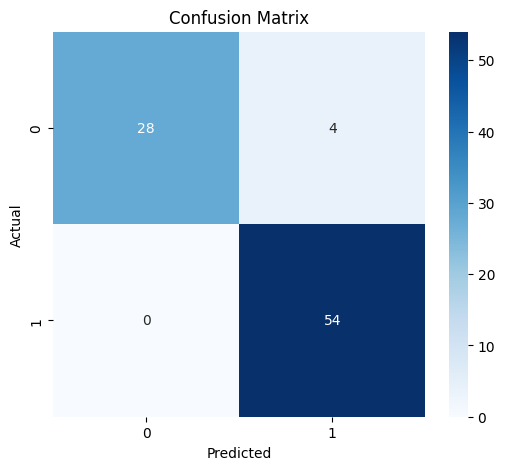

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9872685185185185


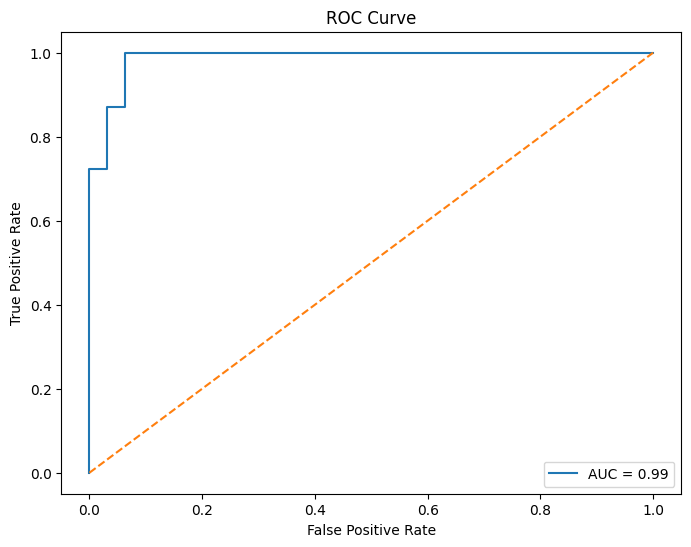

In [22]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [23]:
sample_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print(sample_results.head(10))

   Actual  Predicted   Probability
0       1          1  9.897192e-01
1       0          0  8.760368e-05
2       0          0  1.103304e-04
3       0          0  3.751765e-07
4       0          1  9.477937e-01
5       1          1  8.457683e-01
6       0          1  8.260707e-01
7       1          1  9.960654e-01
8       1          1  6.333601e-01
9       0          0  3.883073e-01


In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

In [25]:
svm_2d = SVC(
    kernel='rbf'
)

svm_2d.fit(X_pca, y_train)

SVC()

In [26]:
x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1

y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

In [27]:
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

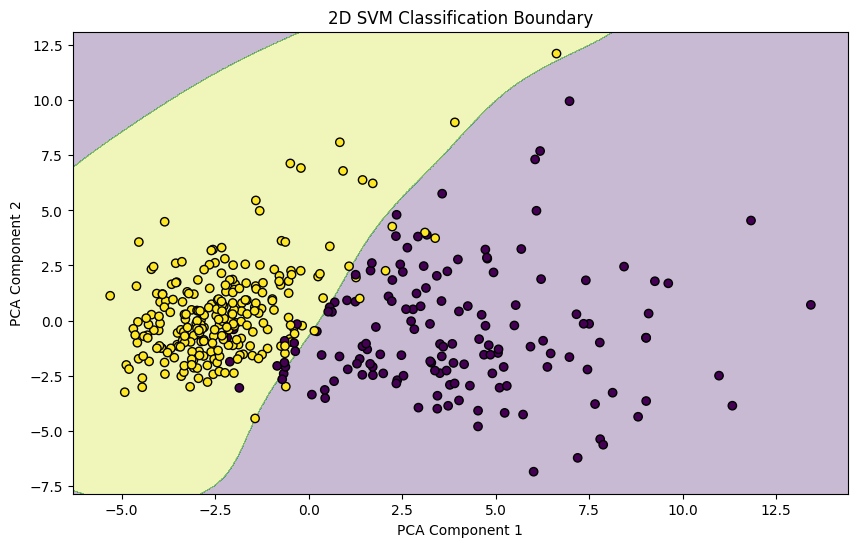

In [28]:
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    edgecolors='k'
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title("2D SVM Classification Boundary")

plt.show()